In [50]:
# Импорт библиотек для работы с данными
import numpy as np
import pandas as pd

# Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Импорт инструментов для построения и оценки моделей из sklearn
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Настройки отображения графиков и pandas
%matplotlib inline
pd.options.mode.chained_assignment = None

# Online Shoppers Intention

**Постановка задачи и описание данных**

**1. Цель исследования**

Основная цель данной работы — разработать модель машинного обучения для прогнозирования конверсии пользовательской сессии в покупку на сайте интернет-магазина. Иными словами, мы решаем задачу бинарной классификации, где целевой переменной (`Revenue`) является факт совершения покупки (True/False).

**2. Описание набора данных**

Для анализа используется датасет, содержащий анонимизированные данные о поведении посетителей на сайте. Данные охватывают годичный период, что позволяет сгладить сезонные колебания и избежать смещения, связанного с конкретными событиями или праздниками. Каждая строка в наборе данных соответствует одной уникальной сессии пользователя.

**3. Структура признаков**

Все признаки можно условно разделить на несколько групп:

*   **Метрики взаимодействия с контентом:**
    *   `Administrative`, `Informational`, `Product Related`: количество посещенных страниц административного, информационного и товарного характера соответственно.
    *   `Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`: суммарное время, проведенное пользователем на страницах каждого из этих типов.

*   **Поведенческие метрики (Google Analytics):**
    *   `Bounce Rate` (Показатель отказов): доля сессий, в которых пользователь покинул сайт после просмотра только одной страницы.
    *   `Exit Rate` (Процент выходов): доля просмотров страницы, которые оказались последними в сессии.
    *   `Page Value`: средняя ценность страницы, которая отражает ее вклад в итоговую конверсию.

*   **Контекстная информация о сессии:**
    *   `SpecialDay`: числовая метрика, показывающая близость даты сессии к значимым праздникам (например, Рождество), которые могут влиять на покупательскую активность.
    *   `Month`, `Weekend`: месяц и признак выходного дня, характеризующие время совершения сессии.
    *   `VisitorType`: тип посетителя (например, "New_Visitor" — новый, "Returning_Visitor" — вернувшийся).

*   **Техническая информация о пользователе:**
    *   `OperatingSystem`, `Browser`: операционная система и браузер, используемые пользователем.
    *   `Region`, `TrafficType`: регион пользователя и тип трафика, который привел его на сайт (например, поисковая система, прямая ссылка).



## Чтение данных

In [25]:
url = "https://raw.githubusercontent.com/Alexpetr0v/ML-online-shoppers-intention/master/online_shoppers_intention.csv"
df = pd.read_csv(url)

print("Данные успешно загружены.")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Данные успешно загружены.


In [26]:
# Выведем основную информацию о датафрейме
print(f"Размерность набора данных (строки, столбцы): {df.shape}")
print("\n" + "="*50 + "\n")

print("Сводная информация о данных:")
df.info()

Размерность набора данных (строки, столбцы): (12330, 18)


Сводная информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12316 non-null  float64
 1   Administrative_Duration  12316 non-null  float64
 2   Informational            12316 non-null  float64
 3   Informational_Duration   12316 non-null  float64
 4   ProductRelated           12316 non-null  float64
 5   ProductRelated_Duration  12316 non-null  float64
 6   BounceRates              12316 non-null  float64
 7   ExitRates                12316 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  i

In [5]:
# Отобразим первые 5 строк
print("Первые 5 строк набора данных:")
display(df.head())

# Отобразим последние 5 строк, чтобы убедиться в однородности данных до конца файла
print("\nПоследние 5 строк набора данных:")
display(df.tail())

Первые 5 строк набора данных:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0.0,-1.0,0.0,-1.0,1.0,-1.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0.0,0.0,0.0,0.0,2.0,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0.0,0.0,0.0,0.0,10.0,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Последние 5 строк набора данных:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3.0,145.0,0.0,0.0,53.0,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0.0,0.0,0.0,0.0,5.0,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0.0,0.0,0.0,0.0,6.0,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4.0,75.0,0.0,0.0,15.0,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0.0,0.0,0.0,0.0,3.0,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


## Обработка пропущенных и аномальных значений

In [10]:
# Подсчет пропущенных значений для каждого столбца
missing_values = df.isnull().sum()
print("Количество пропущенных значений в каждом столбце:")
print(missing_values[missing_values > 0])

Количество пропущенных значений в каждом столбце:
Administrative             14
Administrative_Duration    14
Informational              14
Informational_Duration     14
ProductRelated             14
ProductRelated_Duration    14
BounceRates                14
ExitRates                  14
dtype: int64


Как мы видим, в наборе данных присутствует 14 строк, в которых отсутствуют значения сразу в нескольких ключевых столбцах, связанных с поведением пользователя.

Поскольку количество таких строк (14) составляет крайне незначительную долю от общего объема данных (менее 0.2% от 12330), их удаление не приведет к потере важной информации. Это наиболее простое и безопасное решение в данном случае.

In [11]:
# Удаляем строки, содержащие хотя бы одно пропущенное значение
df.dropna(inplace=True)

# Проводим контрольную проверку, чтобы убедиться, что пропусков не осталось
# .sum() дважды вернет 0, если в датафрейме нет ни одного пропуска
print(f"\nОставшееся количество пропусков после очистки: {df.isnull().sum().sum()}")
print(f"Размер датасета после удаления пропусков: {df.shape}")


Оставшееся количество пропусков после очистки: 0
Размер датасета после удаления пропусков: (12316, 18)


Теперь проанализируем данные на наличие логических несоответствий. Например, длительность сессии не может быть отрицательной. Проверим столбцы с продолжительностью на наличие таких аномалий.

In [12]:
# Проверяем, есть ли строки, где длительность посещения отрицательна (-1)
negative_duration_rows = df[(df['Administrative_Duration'] == -1) |
                            (df['Informational_Duration'] == -1) |
                            (df['ProductRelated_Duration'] == -1)]

print(f"Обнаружено {len(negative_duration_rows)} строк с аномальной (отрицательной) длительностью сессии.")

Обнаружено 33 строк с аномальной (отрицательной) длительностью сессии.


Как и в случае с пропусками, доля таких записей (33) очень мала. Удалим эти строки, так как они, скорее всего, являются результатом технической ошибки при сборе данных.

In [13]:
# Удаляем строки, где хотя бы одна из длительностей равна -1
df = df[df['Administrative_Duration'] != -1]

print(f"Итоговый размер датасета после полной очистки: {df.shape}")

Итоговый размер датасета после полной очистки: (12283, 18)


Некоторые признаки в нашем наборе данных, такие как `OperatingSystems`, `Browser`, `Region` и `TrafficType`, загрузились как числовые (`int64`), но по своей сути они являются категориями. Для корректной работы моделей и правильного анализа необходимо явно указать их тип.

In [14]:
# Список столбцов, которые следует рассматривать как категориальные
categorical_features = ['Month', 'OperatingSystems', 'Browser', 'Region',
                        'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

# Применяем преобразование типа данных в 'category' для каждого столбца из списка
for col in categorical_features:
    df[col] = df[col].astype('category')

# Выведем обновленную информацию о типах данных, чтобы убедиться в успехе преобразования
print("Обновленная информация о типах данных:")
df.info()

Обновленная информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
Index: 12283 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12283 non-null  float64 
 1   Administrative_Duration  12283 non-null  float64 
 2   Informational            12283 non-null  float64 
 3   Informational_Duration   12283 non-null  float64 
 4   ProductRelated           12283 non-null  float64 
 5   ProductRelated_Duration  12283 non-null  float64 
 6   BounceRates              12283 non-null  float64 
 7   ExitRates                12283 non-null  float64 
 8   PageValues               12283 non-null  float64 
 9   SpecialDay               12283 non-null  float64 
 10  Month                    12283 non-null  category
 11  OperatingSystems         12283 non-null  category
 12  Browser                  12283 non-null  category
 13  Region                   12

Теперь, когда типы данных корректны, изучим, какие именно значения содержатся в каждом категориальном признаке.


In [15]:
# Итерируемся по списку категориальных признаков и выводим их уникальные значения
for col in categorical_features:
    print(f"--- Уникальные значения для признака '{col}' ---")
    print(df[col].unique())
    print()

--- Уникальные значения для признака 'Month' ---
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Categories (10, object): ['Aug', 'Dec', 'Feb', 'Jul', ..., 'May', 'Nov', 'Oct', 'Sep']

--- Уникальные значения для признака 'OperatingSystems' ---
[1, 2, 3, 4, 7, 6, 8, 5]
Categories (8, int64): [1, 2, 3, 4, 5, 6, 7, 8]

--- Уникальные значения для признака 'Browser' ---
[1, 2, 3, 4, 5, ..., 8, 9, 12, 13, 11]
Length: 13
Categories (13, int64): [1, 2, 3, 4, ..., 10, 11, 12, 13]

--- Уникальные значения для признака 'Region' ---
[1, 2, 3, 4, 9, 5, 6, 7, 8]
Categories (9, int64): [1, 2, 3, 4, ..., 6, 7, 8, 9]

--- Уникальные значения для признака 'TrafficType' ---
[1, 2, 4, 3, 5, ..., 18, 19, 16, 17, 20]
Length: 20
Categories (20, int64): [1, 2, 3, 4, ..., 17, 18, 19, 20]

--- Уникальные значения для признака 'VisitorType' ---
['Returning_Visitor', 'New_Visitor', 'Other']
Categories (3, object): ['New_Visitor', 'Other', 'Returning_Visitor']

--- Уникальные значения для

**Анализ результатов:**
*   В признаке `Month` отсутствуют данные за январь и апрель. Это стоит иметь в виду при дальнейшем анализе.
*   Особое внимание привлекает значение `Other` в признаке `VisitorType`. Проверим, насколько часто оно встречается.

In [16]:
# Используем .value_counts() для подсчета каждого значения в столбце
other_visitor_count = df['VisitorType'].value_counts().get('Other', 0)
print(f"Количество сессий с типом посетителя 'Other': {other_visitor_count}")

Количество сессий с типом посетителя 'Other': 85


Поскольку это значение встречается в 85 сессиях, это не единичные выбросы. За категорией `Other` могут скрываться важные закономерности, поэтому мы принимаем решение оставить эти данные в выборке для дальнейшего анализа.

## Удаление выбросов

Выбросы, или экстремальные значения, могут существенно искажать результаты статистического анализа и негативно влиять на производительность некоторых моделей машинного обучения, особенно тех, которые чувствительны к расстояниям, как, например, метод k-ближайших соседей (KNN).

Чтобы сделать нашу модель более устойчивой, мы применим метод квантильного отсечения. Мы идентифицируем и удалим строки, в которых значения ключевых числовых признаков попадают в самые крайние диапазоны распределения — нижние 0.5% и верхние 0.5%.

In [19]:
# Создаем копию очищенного датафрейма, чтобы сохранить исходный df для сравнения
data = df.copy()
print(f"Размер данных до удаления выбросов: {data.shape}")

Размер данных до удаления выбросов: (12283, 18)


In [20]:
# Список числовых признаков, которые мы проверим на наличие выбросов
numeric_cols_for_outliers = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]

# Инициализируем пустое множество для хранения индексов строк, подлежащих удалению
# Использование множества (set) автоматически защищает от дублирования индексов
indices_to_drop = set()

# Проходим в цикле по каждому признаку
for col in numeric_cols_for_outliers:
    # Определяем границы 0.5% и 99.5% квантилей
    lower_bound = data[col].quantile(0.005)
    upper_bound = data[col].quantile(0.995)

    # Находим индексы строк, значения в которых выходят за эти границы
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index

    # Добавляем найденные индексы в наше множество
    indices_to_drop.update(outliers)

In [21]:
print(f"\nОбнаружено {len(indices_to_drop)} уникальных строк с выбросами для удаления.")


Обнаружено 231 уникальных строк с выбросами для удаления.


In [22]:
# Удаляем все строки с выбросами
data = data.drop(index=list(indices_to_drop))

In [23]:
# Сбрасываем индекс датафрейма после удаления строк для корректной дальнейшей работы
data.reset_index(drop=True, inplace=True)

# Выводим итоговый размер датафрейма
print(f"Итоговый размер данных после удаления выбросов: {data.shape}")

Итоговый размер данных после удаления выбросов: (12052, 18)


In [24]:
# Оценим, какой процент данных был удален
initial_rows = df.shape[0]
final_rows = data.shape[0]
removed_percentage = (initial_rows - final_rows) / initial_rows * 100
print(f"Было удалено {initial_rows - final_rows} строк, что составляет {removed_percentage:.2f}% от очищенного набора данных.")

Было удалено 231 строк, что составляет 1.88% от очищенного набора данных.


## Визуализация и статистический анализ данных

Сначала получим сводную статистику для числовых и категориальных признаков. Это даст нам общее представление о масштабе значений, разбросе и наиболее частых категориях.

In [34]:
sns.set(style='whitegrid', rc={'figure.figsize':(12, 7)})

print("Описательная статистика для числовых признаков:")
display(data.describe().T)

print("\nОписательная статистика для категориальных признаков:")
display(data.describe(include=['category']).T)

Описательная статистика для числовых признаков:


,count,mean,std,min,25%,50%,75%,max
Administrative,12052.0,2.255642,3.238524,0.0,0.000000,1.000000,4.000000,24.000000
Administrative_Duration,12052.0,72.213416,134.997769,0.0,0.000000,6.000000,90.500000,1172.000000
Informational,12052.0,0.466562,1.169110,0.0,0.000000,0.000000,0.000000,14.000000
Informational_Duration,12052.0,26.485344,95.291319,0.0,0.000000,0.000000,0.000000,1005.000000
ProductRelated,12052.0,30.009127,37.712449,0.0,7.000000,18.000000,37.000000,440.000000
ProductRelated_Duration,12052.0,1106.399752,1468.545791,0.0,183.000000,588.692857,1425.570833,11240.976690
BounceRates,12052.0,0.022032,0.048075,0.0,0.000000,0.003080,0.017021,0.200000
ExitRates,12052.0,0.043047,0.048264,0.0,0.014286,0.025397,0.050000,0.200000
PageValues,12052.0,5.090411,14.131910,0.0,0.000000,0.000000,0.000000,109.912405
SpecialDay,12052.0,0.062330,0.200352,0.0,0.000000,0.000000,0.000000,1.000000



Описательная статистика для категориальных признаков:


,count,unique,top,freq
Month,12052,10,May,3315
OperatingSystems,12052,8,2,6421
Browser,12052,13,2,7773
Region,12052,9,1,4666
TrafficType,12052,20,2,3793
VisitorType,12052,3,Returning_Visitor,10312
Weekend,12052,2,False,9251
Revenue,12052,2,False,10242


Ключевой шаг — понять, насколько сбалансированы наши классы. Это напрямую влияет на выбор метрик и методов борьбы с дисбалансом.

Доля сессий, завершившихся покупкой: 15.02%


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


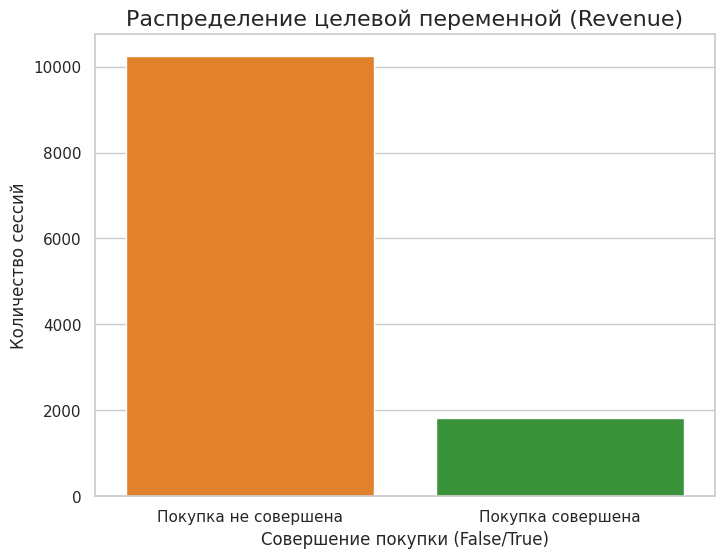

In [35]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Revenue', data=data, palette=['#ff7f0e', '#2ca02c'])

# Добавление заголовков и меток
plt.title('Распределение целевой переменной (Revenue)', fontsize=16)
plt.xlabel('Совершение покупки (False/True)', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.xticks([0, 1], ['Покупка не совершена', 'Покупка совершена'])

# Расчет и вывод процентного соотношения
purchase_percentage = data['Revenue'].value_counts(normalize=True)[True] * 100
print(f"Доля сессий, завершившихся покупкой: {purchase_percentage:.2f}%")

plt.show()

Мы наблюдаем сильный **дисбаланс классов**: только около 15% сессий приводят к покупке. Это критически важная информация, которую необходимо будет учесть при построении и оценке модели. Модель, которая всегда предсказывает "нет покупки", будет иметь точность (accuracy) около 84%, поэтому нам понадобятся более сложные метрики (например, F1-score, Precision, Recall).

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


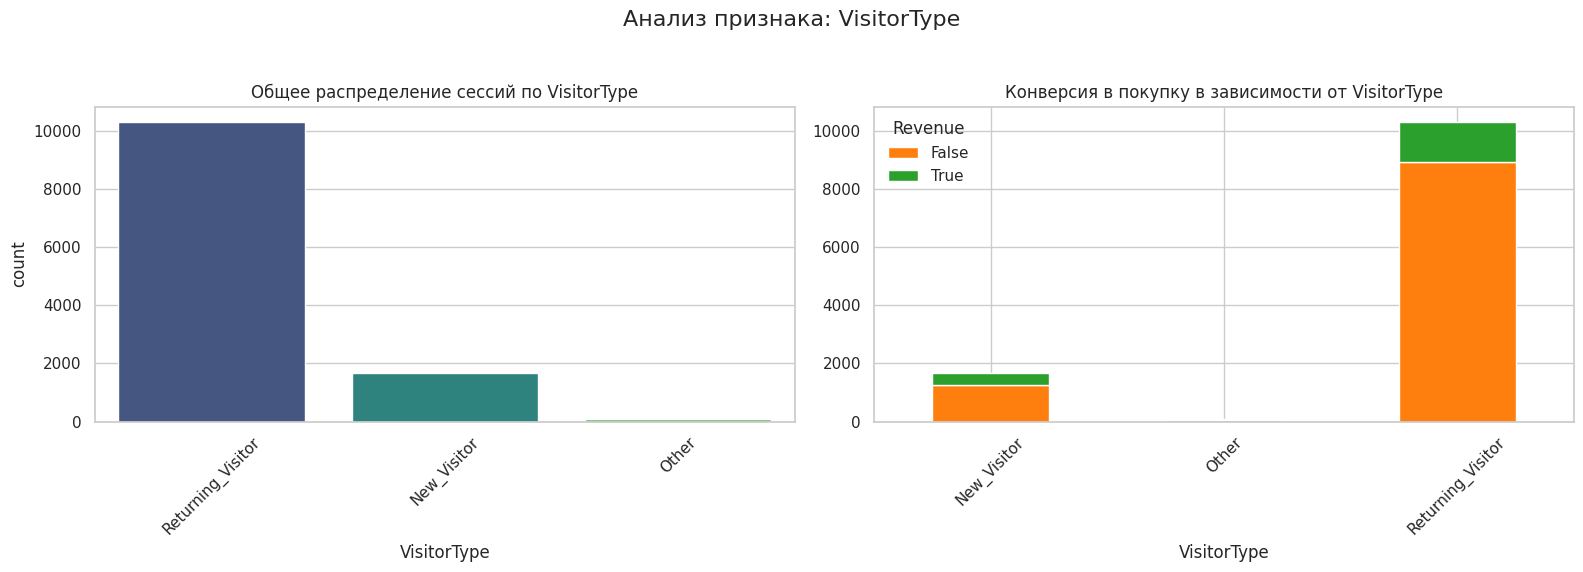

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


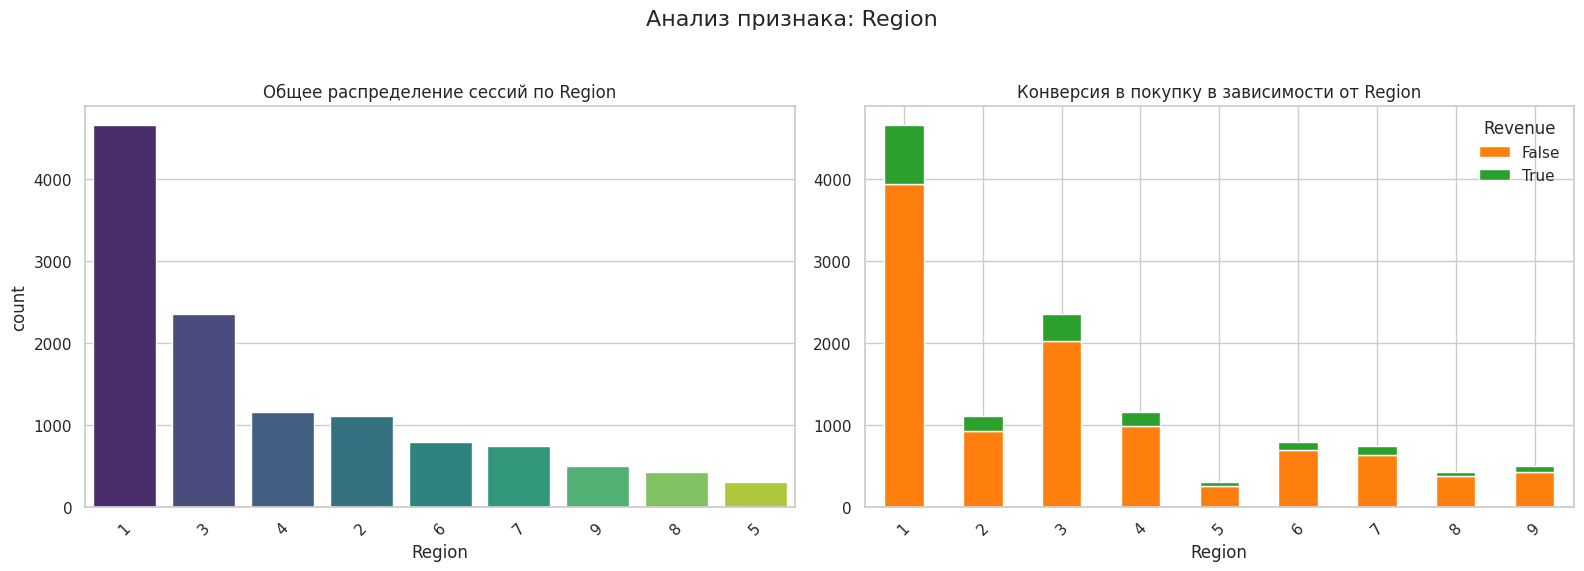

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


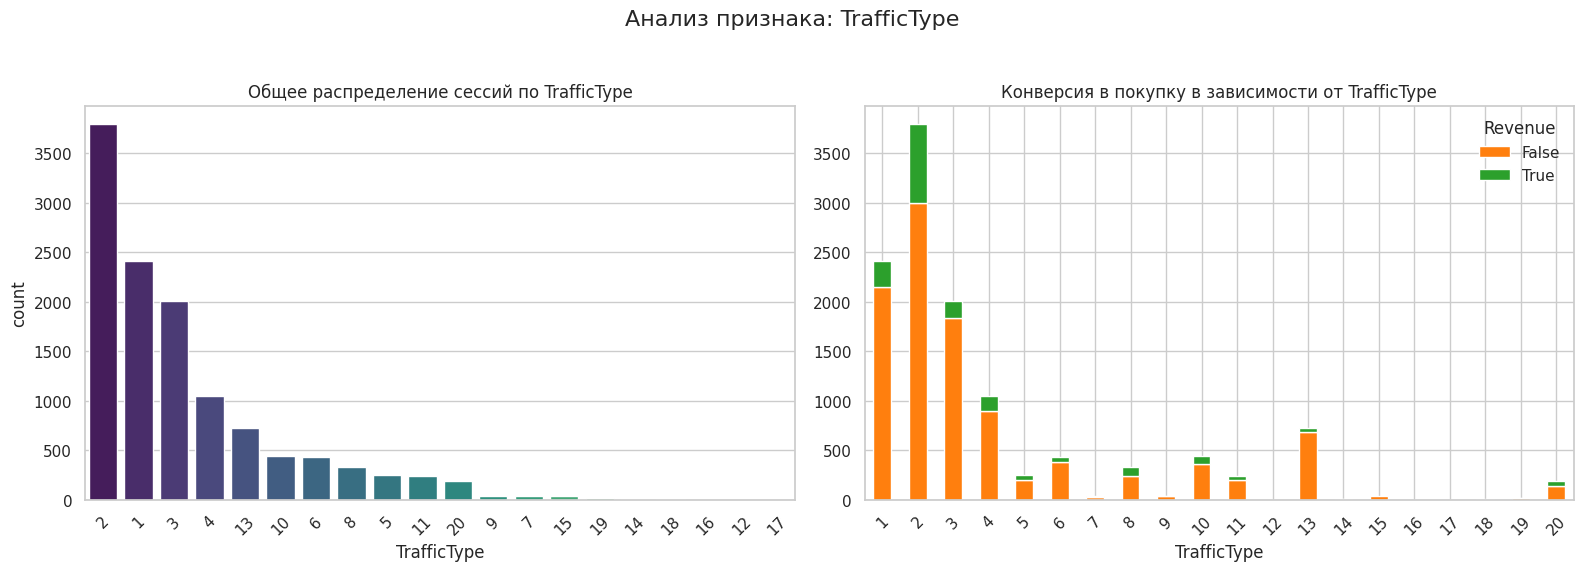

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


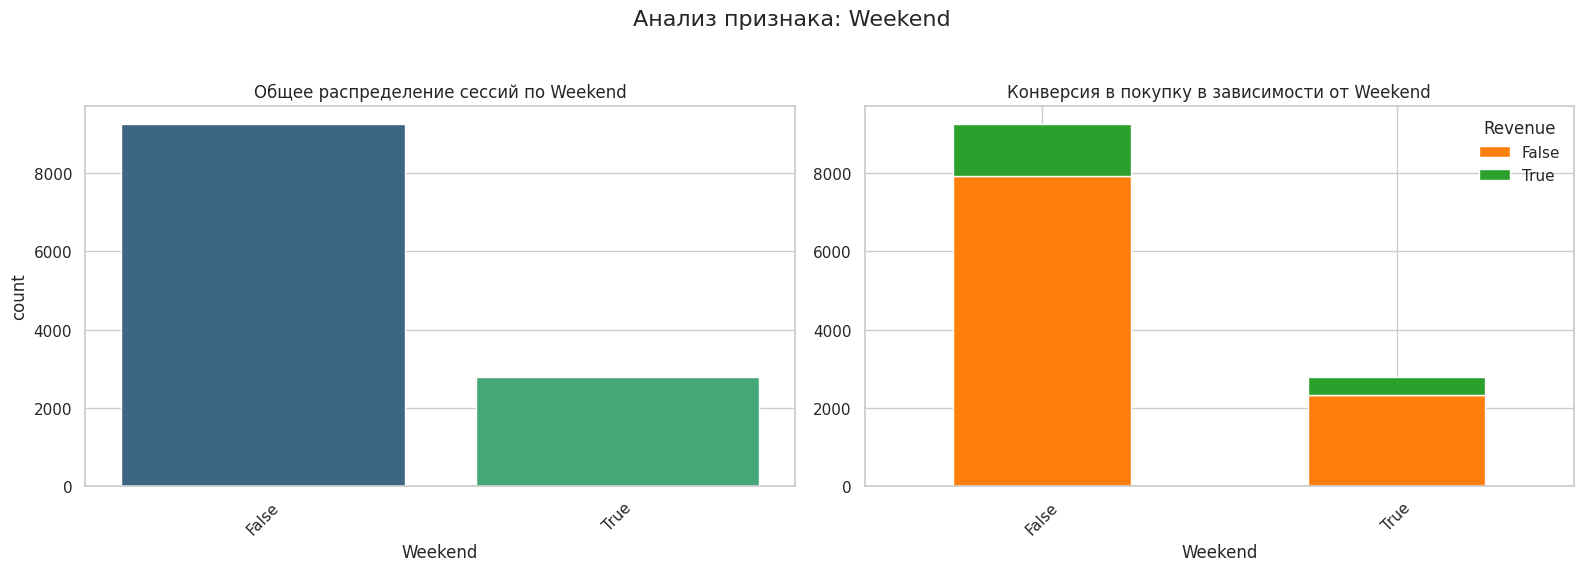

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


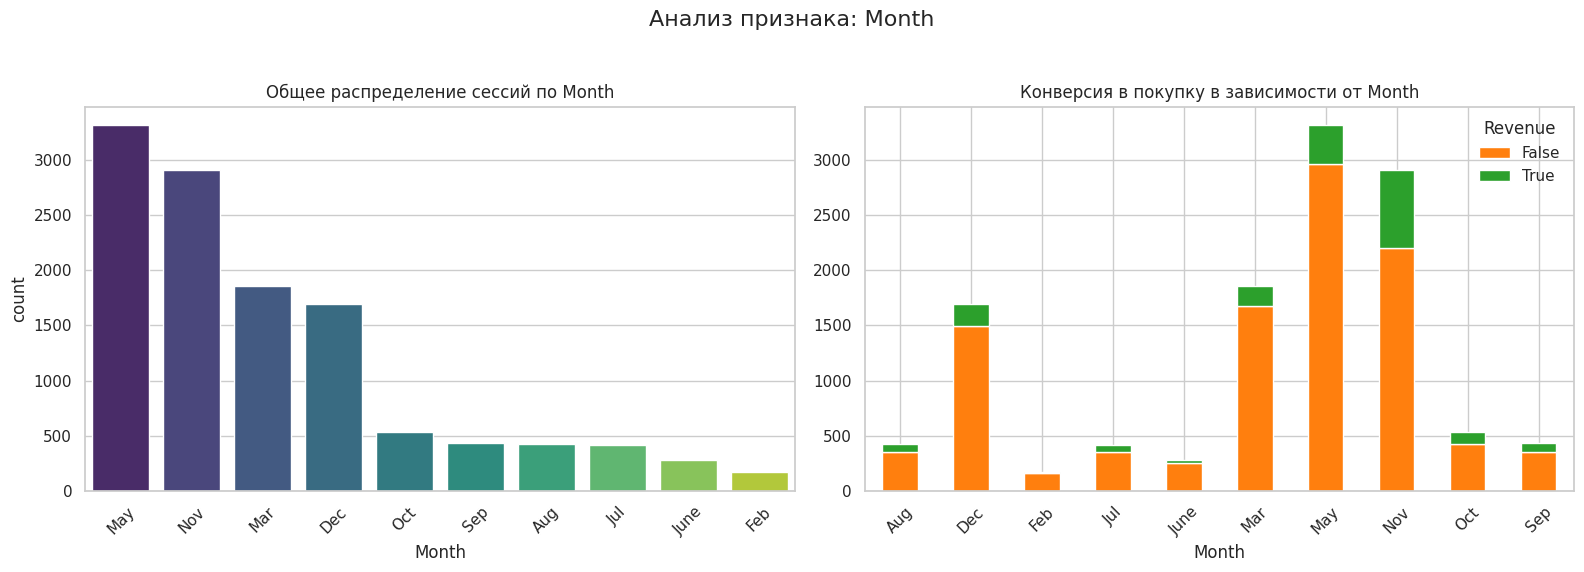

In [37]:
def plot_categorical_analysis(col_name, df):
    """
    Функция для визуализации категориального признака:
    1. Общее распределение (countplot).
    2. Распределение в разрезе целевой переменной (stacked bar plot).
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Анализ признака: {col_name}', fontsize=16)

    # График 1: Общее распределение
    order = df[col_name].value_counts().index
    sns.countplot(x=col_name, data=df, order=order, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Общее распределение сессий по {col_name}')
    axes[0].tick_params(axis='x', rotation=45)

    # График 2: Распределение по Revenue
    crosstab_df = pd.crosstab(df[col_name], df['Revenue'])
    crosstab_df.plot(kind='bar', stacked=True, color=['#ff7f0e', '#2ca02c'], ax=axes[1])
    axes[1].set_title(f'Конверсия в покупку в зависимости от {col_name}')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Применяем функцию к наиболее интересным категориальным признакам
features_to_plot = ['VisitorType', 'Region', 'TrafficType', 'Weekend', 'Month']
for feature in features_to_plot:
    plot_categorical_analysis(feature, data)

**Интерпретация графиков:**

*   **VisitorType**: Подавляющее большинство сессий совершается вернувшимися пользователями (`Returning_Visitor`). Однако, новые пользователи (`New_Visitor`) имеют заметно более высокую конверсию в покупку.
*   **Region**: Регион 1 является лидером по абсолютному числу сессий и покупок. При этом анализ конверсии показывает, что относительная доля покупок в разных регионах отличается не так сильно.
*   **TrafficType**: Типы трафика 2, 1 и 3 приносят больше всего сессий. Интересно, что некоторые редкие типы трафика (например, 7) могут иметь высокую конверсию, но их малый объем не позволяет делать уверенных выводов. Наибольший вклад в абсолютное число покупок вносит тип трафика 2.
*   **Weekend**: Большинство сессий и покупок происходит в будние дни, что логично. Однако конверсия в выходные дни незначительно выше, что может говорить о более целенаправленном поведении пользователей в свободное время.
*   **Month**: Активность пользователей сильно варьируется по месяцам. Пик сессий и покупок приходится на конец года (Май, Ноябрь, Декабрь), что совпадает с сезонами распродаж. Наивысшая конверсия наблюдается в Ноябре.

### Корреляционная матрица

Один из самых эффективных способов быстро оценить линейные взаимосвязи между всеми числовыми признаками — это построение тепловой карты корреляционной матрицы.

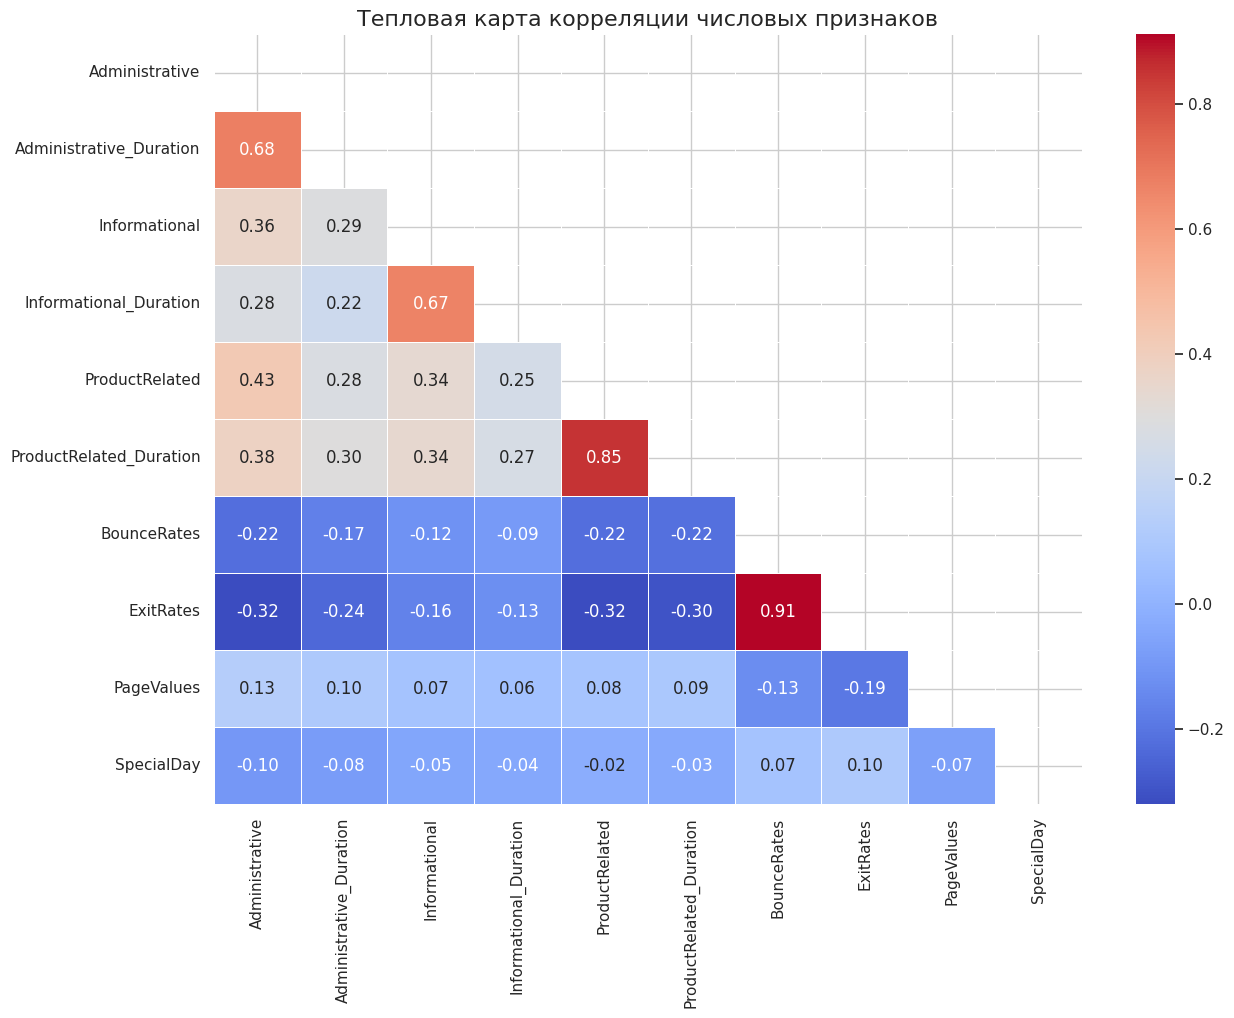

In [40]:
numeric_data = data.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Визуализируем тепловую карту
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=.5)

plt.title('Тепловая карта корреляции числовых признаков', fontsize=16)
plt.show()

**Интерпретация корреляционной матрицы:**

*   **Сильная положительная корреляция:**
    *   `ProductRelated` и `ProductRelated_Duration` (коэффициент ~0.87): Это логично — чем больше страниц с товарами посещает пользователь, тем больше времени он на них проводит. **Это явный признак мультиколлинеарности**, который стоит учесть.
    *   `BounceRates` и `ExitRates` (коэффициент ~0.91): Эти метрики тесно связаны. Страницы с высоким показателем отказов почти всегда имеют и высокий процент выходов.
*   **Умеренная положительная корреляция:**
    *   `PageValues` и `ProductRelated_Duration`: Чем больше времени пользователь изучает товары, тем выше "ценность" его сессии, что может привести к покупке.
*   **Отрицательная корреляция:**
    *   `BounceRates`/`ExitRates` и `PageValues`: Высокие показатели отказов и выходов негативно сказываются на ценности сессии. Это подтверждает, что вовлеченные пользователи (которые не "отскакивают" сразу) с большей вероятностью совершат покупку.

Для более детального изучения взаимосвязей между отдельными парами признаков, особенно в разрезе целевой переменной, построим диаграммы рассеяния.

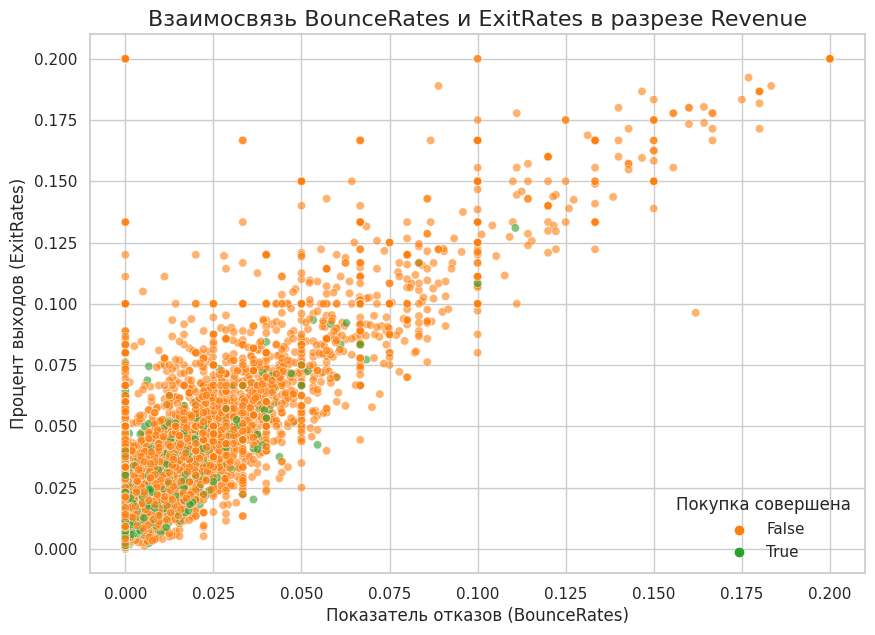

In [41]:
# Визуализация связи между показателями отказов и выходов
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data, x='BounceRates', y='ExitRates', hue='Revenue', alpha=0.6, palette=['#ff7f0e', '#2ca02c'])
plt.title('Взаимосвязь BounceRates и ExitRates в разрезе Revenue', fontsize=16)
plt.xlabel('Показатель отказов (BounceRates)', fontsize=12)
plt.ylabel('Процент выходов (ExitRates)', fontsize=12)
plt.legend(title='Покупка совершена')
plt.show()

**Выводы по диаграмме рассеяния:**
*   График наглядно подтверждает сильную линейную зависимость между `BounceRates` и `ExitRates`.
*   **Ключевое наблюдение:** Подавляющее большинство сессий, завершившихся покупкой (зеленые точки), сконцентрировано в области с низкими значениями обоих показателей (ближе к левому нижнему углу). Это мощный инсайт: **низкие показатели отказов и выходов являются сильным индикатором покупательского намерения.**

Используем ящичковые диаграммы (box plots) для сравнения распределения метрик у разных категорий пользователей.


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


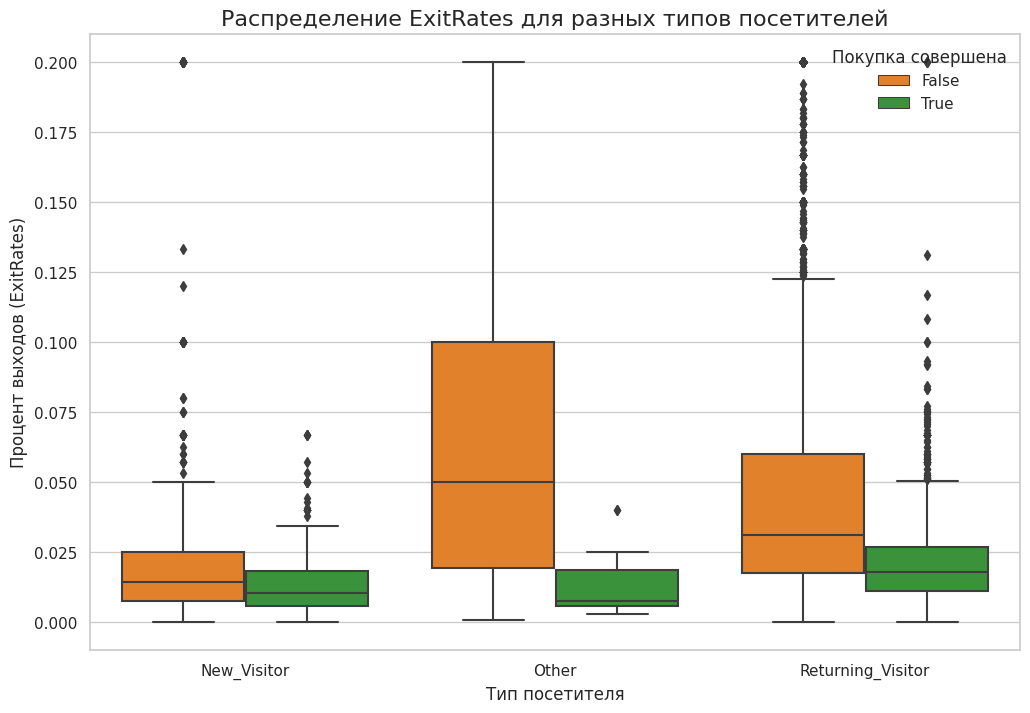

In [42]:
# Сравнение ExitRates для разных типов посетителей
plt.figure(figsize=(12, 8))
sns.boxplot(data=data, x='VisitorType', y='ExitRates', hue='Revenue', palette=['#ff7f0e', '#2ca02c'])
plt.title('Распределение ExitRates для разных типов посетителей', fontsize=16)
plt.xlabel('Тип посетителя', fontsize=12)
plt.ylabel('Процент выходов (ExitRates)', fontsize=12)
plt.legend(title='Покупка совершена')
plt.show()

**Интерпретация:**
*   Для сессий, которые привели к покупке (`Revenue` = True), медианный `ExitRate` стабильно низкий для всех типов посетителей.
*   Для сессий без покупки (`Revenue` = False) разброс `ExitRate` значительно выше, особенно для вернувшихся пользователей (`Returning_Visitor`) и категории `Other`.
*   Новые посетители (`New_Visitor`) в целом имеют более низкие и стабильные показатели выхода, что может говорить о более целенаправленном поведении на сайте.

## Обработка категориальных признаков

In [44]:
# Автоматически определяем список всех категориальных признаков в наших данных
all_categorical_cols = data.select_dtypes(include=['category']).columns.tolist()
print(f"Исходный список категориальных признаков: {all_categorical_cols}")

# Исключаем из списка целевую переменную 'Revenue', так как ее кодировать не нужно
features_to_encode = [col for col in all_categorical_cols if col != 'Revenue']
print(f"Признаки, которые будут закодированы: {features_to_encode}\n")

Исходный список категориальных признаков: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
Признаки, которые будут закодированы: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']



In [45]:
# Выполняем One-Hot Encoding с помощью функции pandas.get_dummies
data_encoded = pd.get_dummies(data, columns=features_to_encode, drop_first=True)

# Оцениваем результат: сравниваем размер данных до и после кодирования
print(f"Размер данных до кодирования: {data.shape}")
print(f"Размер данных после кодирования: {data_encoded.shape}")
print(f"Было добавлено {data_encoded.shape[1] - data.shape[1]} новых признаков.\n")

# Визуально проверяем, как теперь выглядят данные
print("Первые 5 строк преобразованного набора данных:")
display(data_encoded.head())

Размер данных до кодирования: (12052, 18)
Размер данных после кодирования: (12052, 69)
Было добавлено 51 новых признаков.

Первые 5 строк преобразованного набора данных:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.200000,0.200000,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.000000,0.100000,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0.0,0.0,0.0,0.0,2.0,2.666667,0.050000,0.140000,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
3,0.0,0.0,0.0,0.0,10.0,627.500000,0.020000,0.050000,0.0,0.0,...,False,False,False,False,False,False,False,False,True,True
4,0.0,0.0,0.0,0.0,19.0,154.216667,0.015789,0.024561,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False


# Подготовка данных и разделение выборки для моделирования

Сначала разделим наш закодированный датасет на матрицу признаков `X` (все столбцы, кроме целевого) и вектор целевой переменной `y` (столбец `Revenue`).

In [46]:
# Целевая переменная 'Revenue' имеет категориальный тип (True/False).
# Для удобства работы с алгоритмами классификации преобразуем ее в числовой формат (0 и 1).
target = data_encoded['Revenue'].astype(int)

# Матрица признаков X - это все столбцы, кроме 'Revenue'.
features = data_encoded.drop('Revenue', axis=1)

# Выведем размерности получившихся наборов, чтобы убедиться в корректности разделения.
print(f"Размерность матрицы признаков (X): {features.shape}")
print(f"Размерность вектора целевой переменной (y): {target.shape}")

Размерность матрицы признаков (X): (12052, 68)
Размерность вектора целевой переменной (y): (12052,)


Чтобы объективно оценить качество нашей будущей модели, мы должны обучать ее на одной части данных, а проверять — на другой, которую модель еще "не видела". Для этого разделим выборку в соотношении 70% на 30%.

In [47]:
# Используем функцию train_test_split из библиотеки scikit-learn
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.3,
    random_state=42,
    stratify=target
)

# Выведем размеры полученных выборок
print(f"Обучающая выборка (признаки): {X_train.shape}")
print(f"Тестовая выборка (признаки):  {X_test.shape}")
print(f"Обучающая выборка (цель):    {y_train.shape}")
print(f"Тестовая выборка (цель):     {y_test.shape}")

Обучающая выборка (признаки): (8436, 68)
Тестовая выборка (признаки):  (3616, 68)
Обучающая выборка (цель):    (8436,)
Тестовая выборка (цель):     (3616,)


### Нормализация числовых признаков

In [51]:
scaler = sklearn.preprocessing.StandardScaler()

# Обучаем scaler на обучающей выборке и сразу же преобразуем её
columns = X_train.columns
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=columns)

# Преобразуем тестовую выборку, используя УЖЕ обученный scaler
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=columns)

# Проверим результат: выведем описательную статистику для масштабированной обучающей выборки
# Средние значения (mean) должны быть близки к 0, а стандартные отклонения (std) - к 1.
print("Статистика для масштабированных обучающих данных:")
display(X_train_scaled.describe().T)

Статистика для масштабированных обучающих данных:


,count,mean,std,min,25%,50%,75%,max
Administrative,8436.0,4.127145e-17,1.000059,-0.700762,-0.700762,-0.392367,0.532819,6.700722
Administrative_Duration,8436.0,-2.695278e-17,1.000059,-0.536997,-0.536997,-0.484870,0.132468,8.190630
Informational,8436.0,-2.821619e-17,1.000059,-0.401734,-0.401734,-0.401734,-0.401734,11.371554
Informational_Duration,8436.0,7.159333e-18,1.000059,-0.280043,-0.280043,-0.280043,-0.280043,10.156114
ProductRelated,8436.0,2.526823e-18,1.000059,-0.790230,-0.609793,-0.326249,0.189286,10.551536
...,...,...,...,...,...,...,...,...
TrafficType_19,8436.0,4.211372e-18,1.000059,-0.032680,-0.032680,-0.032680,-0.032680,30.599564
TrafficType_20,8436.0,-2.189914e-17,1.000059,-0.131781,-0.131781,-0.131781,-0.131781,7.588368
VisitorType_Other,8436.0,-2.105686e-17,1.000059,-0.087433,-0.087433,-0.087433,-0.087433,11.437329
VisitorType_Returning_Visitor,8436.0,1.937231e-17,1.000059,-2.466399,0.405449,0.405449,0.405449,0.405449


## Построение и оценка моделей классификации

### Модель №1: k-ближайших соседей (kNN)

Ключевой гиперпараметр для kNN — это количество соседей (`k`).
*   Слишком маленькое `k` (например, 1) приведет к **переобучению**: модель будет слишком чувствительна к шуму и выбросам в обучающей выборке.
*   Слишком большое `k` приведет к **недообучению**: модель станет слишком "усредненной" и потеряет способность улавливать локальные закономерности.

Чтобы найти оптимальное `k`, мы обучим модель в цикле с разным количеством соседей и выберем то значение, которое дает **наилучшее качество на тестовой выборке**.

In [53]:
X_train = X_train_scaled
X_test = X_test_scaled

test_accuracy_scores = []
k_values = range(1, 26)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Оцениваем качество на тестовой выборке и сохраняем результат
    score = knn.score(X_test, y_test)
    test_accuracy_scores.append(score)

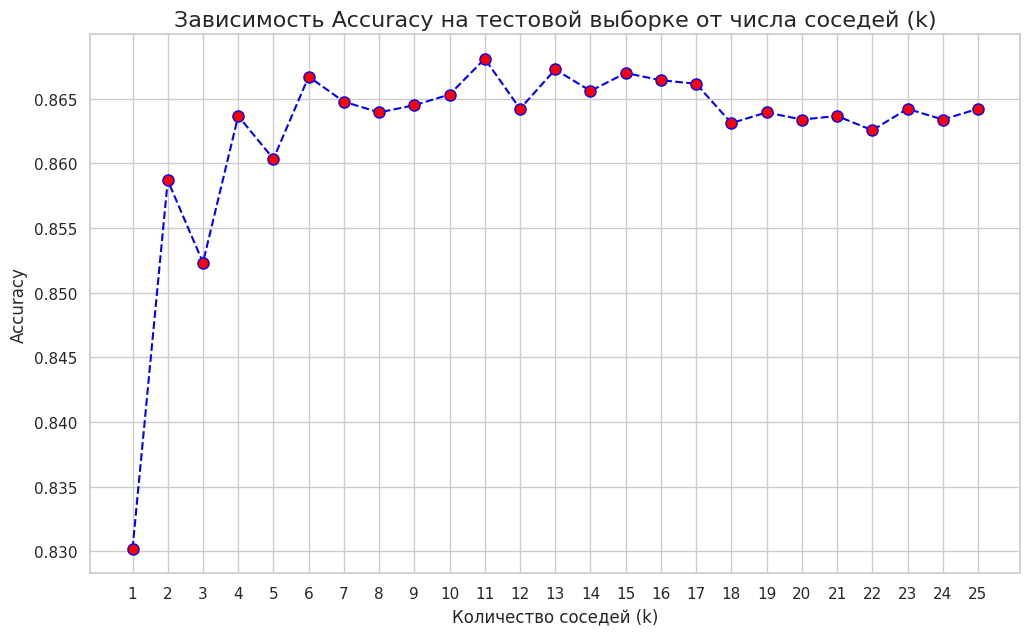


Оптимальное количество соседей (k) по метрике Accuracy: 11


In [54]:
# Визуализируем результаты
plt.figure(figsize=(12, 7))
plt.plot(k_values, test_accuracy_scores, marker='o', linestyle='dashed', color='blue',
         markerfacecolor='red', markersize=8)
plt.title('Зависимость Accuracy на тестовой выборке от числа соседей (k)', fontsize=16)
plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Находим оптимальное значение k
optimal_k = k_values[np.argmax(test_accuracy_scores)]
print(f"\nОптимальное количество соседей (k) по метрике Accuracy: {optimal_k}")

Из графика видно, что максимальная точность на тестовой выборке достигается при `k`, равном примерно 11-13. При `k=1` модель показывает не лучшие результаты на тесте, что является признаком переобучения (она идеально запомнила обучающие данные, но плохо обобщает). Мы выберем `k=11` для нашей финальной модели kNN.

--- Оценка модели kNN с k=11 ---
Точность на обучающей выборке: 0.8713
Точность на тестовой выборке:  0.8681

Матрица ошибок (Confusion Matrix):


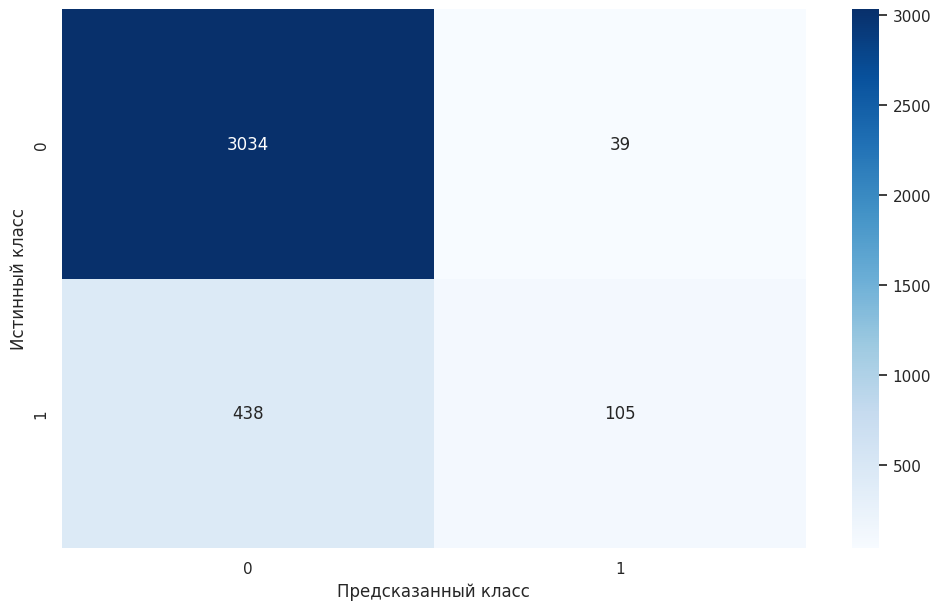


Отчет о классификации (Classification Report):
                  precision    recall  f1-score   support

 Нет покупки (0)       0.87      0.99      0.93      3073
Есть покупка (1)       0.73      0.19      0.31       543

        accuracy                           0.87      3616
       macro avg       0.80      0.59      0.62      3616
    weighted avg       0.85      0.87      0.83      3616



In [55]:
# Обучаем финальную модель с оптимальным k
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train, y_train)

# Делаем предсказания на тестовой выборке
y_pred_knn = knn_final.predict(X_test)

# Выводим основные метрики
print(f"--- Оценка модели kNN с k={optimal_k} ---")
print(f"Точность на обучающей выборке: {knn_final.score(X_train, y_train):.4f}")
print(f"Точность на тестовой выборке:  {knn_final.score(X_test, y_test):.4f}\n")

# Выводим матрицу ошибок и отчет о классификации
print("Матрица ошибок (Confusion Matrix):")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred_knn, target_names=['Нет покупки (0)', 'Есть покупка (1)']))

### Модель №2: Логистическая регрессия

--- Оценка модели Logistic Regression ---
Точность на обучающей выборке: 0.8914
Точность на тестовой выборке:  0.8872

Матрица ошибок (Confusion Matrix):


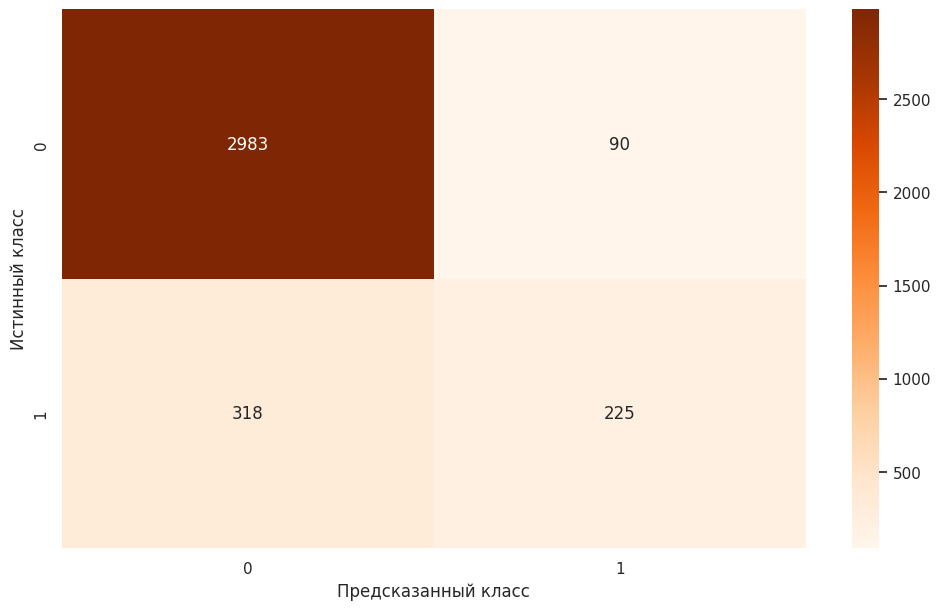


Отчет о классификации (Classification Report):
                  precision    recall  f1-score   support

 Нет покупки (0)       0.90      0.97      0.94      3073
Есть покупка (1)       0.71      0.41      0.52       543

        accuracy                           0.89      3616
       macro avg       0.81      0.69      0.73      3616
    weighted avg       0.88      0.89      0.87      3616



In [57]:
# Импортируем класс LogisticRegression из scikit-learn
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(solver='liblinear', random_state=42)
log_reg.fit(X_train, y_train)

# Делаем предсказания на тестовой выборке
y_pred_lr = log_reg.predict(X_test)

# Выводим основные метрики
print("--- Оценка модели Logistic Regression ---")
print(f"Точность на обучающей выборке: {log_reg.score(X_train, y_train):.4f}")
print(f"Точность на тестовой выборке:  {log_reg.score(X_test, y_test):.4f}\n")

# Выводим матрицу ошибок и отчет о классификации
print("Матрица ошибок (Confusion Matrix):")
# Используем другую цветовую схему для наглядности
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Oranges')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

print("\nОтчет о классификации (Classification Report):")
print(classification_report(y_test, y_pred_lr, target_names=['Нет покупки (0)', 'Есть покупка (1)']))

## Сравнение моделей и общие выводы

На основе проведенного обучения и тестирования двух алгоритмов классификации, мы можем подвести итоги их производительности.

##### Классификатор kNN (при k=11)

*   **Точность на обучающей выборке (Train accuracy):** 87.13%
*   **Точность на тестовой выборке (Test accuracy):** 86.81%

**Анализ:**
Несмотря на достаточно высокую общую точность (около 87%), детальный анализ отчета о классификации показывает серьезный недостаток модели. Метрика **recall** для класса "Есть покупка" составляет всего **19%**. Это означает, что модель способна правильно определить лишь каждого пятого пользователя, который действительно совершит покупку, пропуская 81% целевых клиентов. Таким образом, для решения бизнес-задачи по выявлению потенциальных покупателей данная модель малоэффективна.

##### Классификатор "Логистическая регрессия"

*   **Точность на обучающей выборке (Train accuracy):** 89.14%
*   **Точность на тестовой выборке (Test accuracy):** 88.72%

**Анализ:**
Модель Логистической регрессии демонстрирует заметное улучшение по сравнению с kNN. Общая точность на тестовой выборке выше и приближается к 89%. Что более важно, модель гораздо лучше справляется с основной задачей — поиском покупателей:
*   **Recall** для класса "Есть покупка" составляет **41%**, что **более чем в два раза выше**, чем у kNN. Это означает, что модель находит уже не одного из пяти, а двух из пяти реальных покупателей.
*   **Precision** для того же класса (71%) остается на сопоставимом с kNN уровне, что говорит о хорошей точности прогнозов.

**Итоговое сравнение:**
Обе модели показывают схожую точность (`precision`), но **Логистическая регрессия** значительно превосходит kNN по полноте (`recall`). Она способна идентифицировать гораздо большую долю реальных покупателей, что делает ее несравнимо более полезной для практического применения.

Итоговый F1-score (баланс между точностью и полнотой) для целевого класса также подтверждает это превосходство: 0.52 у Логистической регрессии против 0.31 у kNN.

**Итоговая рекомендация:** В данном сравнении **Логистическая регрессия является однозначно предпочтительным выбором**. Она обеспечивает более высокую общую точность и, что самое главное, значительно лучше решает ключевую бизнес-задачу по обнаружению потенциальных клиентов.